
## BÁO CÁO THỰC THI TIỂU LUẬN MÔN KHOA HỌC DỮ LIỆU

### ĐỀ TÀI: DỰ ĐOÁN MỨC LƯƠNG KỲ VỌNG CỦA CÁC VỊ TRÍ TUYỂN DỤNG TẠI VIỆT NAM DỰA TRÊN MÔ TẢ CÔNG VIỆC VÀ YÊU CẦU ỨNG VIÊN SỬ DỤNG MÔ HÌNH HỌC MÁY

**Nhóm thực hiện:** Nhóm 15  
**Thành viên:**  
1. Ngô Văn Công  
2. Võ Minh Hiếu  
3. Nguyễn Phan Tuấn Anh

---

# CHƯƠNG 1: GIỚI THIỆU & MÔ TẢ BÀI TOÁN

## 1. Mục tiêu đề tài
Đề tài tập trung xây dựng hệ thống học máy dự đoán mức lương kì vọng dựa trên bản mô tả công việc (Job Description - JD) và thông tin tuyển dụng đi kèm (địa điểm, loại công việc, cấp bậc yêu cầu).

## 2. Định nghĩa toán học của bài toán Hồi quy
Gọi $X$ là tập các đặc trưng (features) trích xuất từ tin tuyển dụng bao gồm đặc trưng văn bản (Textual Features) và đặc trưng phân loại (Categorical Features). Mục tiêu là xây dựng hàm dự báo $f(X)$ sao cho sai số với mức lương kỳ vọng thực tế $y$ là nhỏ nhất.

Lương kỳ vọng thực tế được xác định theo công thức:
$$y = \text{Expected Salary} = \frac{\text{Salary Min} + \text{Salary Max}}{2}$$

## 3. Các chỉ số đánh giá học thuật
- **Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
- **Mean Absolute Error (MAE):**
$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
- **Coefficient of Determination ($R^2$):**
$$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$
- **Range Accuracy Metric (RAM - Độ chính xác khoảng):**
$$RAM = \frac{1}{N} \sum_{i=1}^{N} I(\hat{y}_i \in [y_{i, \text{min}} - \epsilon, y_{i, \text{max}} + \epsilon])$$
Trong đó $I$ là hàm chỉ thị, $\epsilon = 1.0$ (triệu VNĐ) là sai số chấp nhận được.

### 1. Khai báo các thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42

# CHƯƠNG 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Trong chương này, chúng ta tiến hành khảo sát cấu trúc dữ liệu thô ban đầu để nắm bắt đặc tính phân phối.

In [ ]:
# Đọc dữ liệu train thô
print("Đang nạp dữ liệu train...")
raw_train = pd.read_csv('raw_data_train.csv')
print(f"Kích thước dữ liệu train thô: {raw_train.shape[0]:,} dòng, {raw_train.shape[1]} cột.")
raw_train.head(3)

Đang nạp dữ liệu train...


Kích thước dữ liệu train thô: 30,000 dòng, 14 cột.


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year
0,31244,Business Development Director (Bdd),Công Ty Cổ Phần Công Nghệ Bất Động Sản Mgi,VND MONTH,"Ho Chi Minh City Lầu 3, Tòa nhà SAMCO, 326 Võ ...",Toàn thời gian,Bất động sản,2 năm,Cao đẳng,Giám đốc,"· Quản lý, xây dựng và chăm sóc các mối quan h...","· Lương cạnh tranh, thỏa thuận theo năng lực. ...",· Tốt nghiệp từ Cao đẳng trở lên,2026
1,36886,Nhân Viên Kế Toán Tổng Hợp,Công Ty TNHH A.A.C.C,10000000 - 15000000 VND MONTH,"Ho Chi Minh City 90 đường 52 , Phường Bình Trư...",Toàn thời gian,Kế toán / Kiểm toán,1 năm,Đại học,Chuyên gia,"Sắp xếp, kiểm tra, lưu trữ hóa đơn, chứng từ. ...",Lương khởi điểm từ 10.000.000 ( ứng viên có ki...,"Tốt nghiệp Đại học chuyên ngành Kế toán, Kiểm ...",2022
2,37424,Nhân Viên Kinh Doanh (Lĩnh Vực Thẩm Định Giá),Công Ty TNHH Thẩm Định Giá Hoàng Quân,7000000 - 10000000 VND MONTH,"Ho Chi Minh City 177 Trần Huy Liệu, Q.Phú Nhuậ...",Toàn thời gian,Bán hàng - Kinh doanh,Dưới 1 năm,Trung cấp,Chưa cập nhật,Nhận thông tin khách hàng có nhu cầu từ các đố...,"Làm việc từ T2-T6, nghỉ T7, CN - Tham gia Bảo ...",Tốt nghiệp Trung cấp - Ưu tiên có kinh nghiệm ...,2022


In [ ]:
# Khảo sát chất lượng dữ liệu khuyết thiếu
missing_data = raw_train.isnull().sum().to_frame(name='Missing Count')
missing_data['Percentage (%)'] = (missing_data['Missing Count'] / len(raw_train)) * 100
print("\n--- Thống kê giá trị thiếu --- ")
print(missing_data[missing_data['Missing Count'] > 0])


--- Thống kê giá trị thiếu --- 
                 Missing Count  Percentage (%)
job_title                    7        0.023333
company_name                 2        0.006667
job_position               108        0.360000
job_description              5        0.016667
benefits                  1693        5.643333
requirements              2850        9.500000


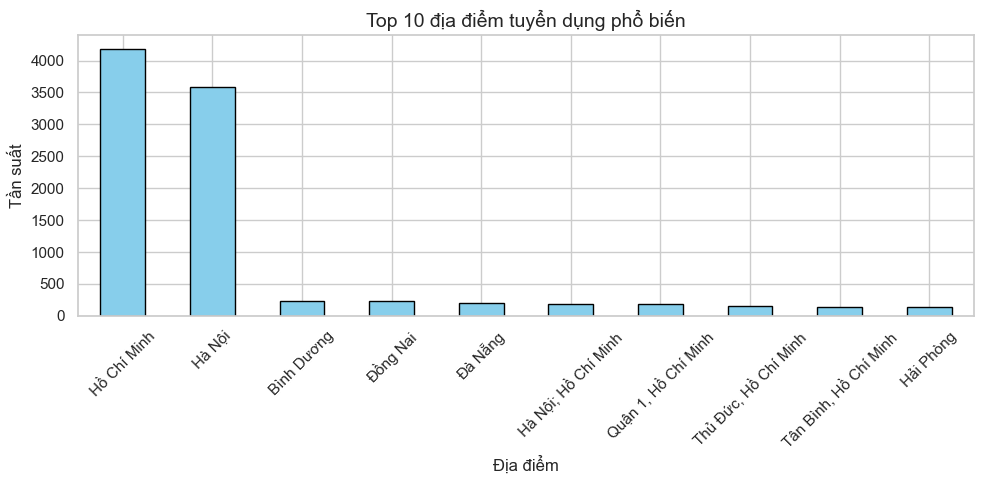

In [ ]:
# Trực quan hóa Top 10 địa điểm tuyển dụng phổ biến nhất
plt.figure(figsize=(10, 5))
raw_train['location'].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 địa điểm tuyển dụng phổ biến', fontsize=14)
plt.xlabel('Địa điểm')
plt.ylabel('Tần suất')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# CHƯƠNG 3: QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU

Bước này đóng vai trò quan trọng nhất nhằm trích xuất thông tin lương từ văn bản và loại bỏ các nhiễu/outliers khỏi tập dữ liệu học máy.

In [ ]:
def extract_salary_features(salary_str):
    """
    Hàm Regex trích xuất Min, Max và tính Expected Salary từ cột salary dạng text.
    Ví dụ: '15 - 20 triệu' -> (15.0, 20.0, 17.5)
    """
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    
    numbers = [float(n) for n in re.findall(r"\d+\.?\d*", s)]
    numbers = [n for n in numbers if n < 1000]  # Loại bỏ năm
    
    if not numbers:
        return np.nan, np.nan, np.nan
    
    if len(numbers) >= 2:
        return numbers[0], numbers[1], float(np.mean(numbers[:2]))
    else:
        return numbers[0], numbers[0], numbers[0]

VIET_STOPWORDS = {
    'và', 'là', 'các', 'cho', 'có', 'không', 'được', 'trên', 'từ', 'với', 'khi', 'một', 'những',
    'này', 'đó', 'vào', 'tại', 'theo', 'cũng', 'đến', 'để', 'cần', 'sẽ', 'đã', 'đang', 'nên'
}

def clean_text(text):
    if pd.isna(text):
        return ""
    s = str(text).lower()
    s = re.sub(
        r"[^a-zA-Z0-9áàạảãâầấậẩẫăằắặẳẵđéèẹẻẽêềếệểễíìịỉĩóòọỏõôồốộổỗơờớợởỡúùụủũưừứựửữýỳỵỷỹ\s]",
        " ",
        s
    )
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [t for t in s.split() if t not in VIET_STOPWORDS]
    return " ".join(tokens)

def normalize_location(location):
    if pd.isna(location):
        return "Khac"
    s = str(location).lower()
    mapping = {
        'ho chi minh': 'Ho Chi Minh',
        'hcm': 'Ho Chi Minh',
        'ha noi': 'Ha Noi',
        'hn': 'Ha Noi',
        'da nang': 'Da Nang',
        'binh duong': 'Binh Duong',
        'dong nai': 'Dong Nai',
        'hai phong': 'Hai Phong',
        'can tho': 'Can Tho',
        'bac ninh': 'Bac Ninh',
        'quang ninh': 'Quang Ninh'
    }
    for key, value in mapping.items():
        if key in s:
            return value
    return "Khac"

def extract_experience_years(exp):
    if pd.isna(exp):
        return np.nan
    s = str(exp).lower()
    if 'dưới' in s or 'duoi' in s:
        return 0.5
    if 'khong' in s and 'yeu cau' in s:
        return 0
    numbers = [float(n) for n in re.findall(r"\d+\.?\d*", s)]
    if not numbers:
        return np.nan
    if len(numbers) >= 2:
        return float(np.mean(numbers[:2]))
    return float(numbers[0])

# Tiến hành trích xuất cho tập Train
print("Đang trích xuất cột lương...")
salary_features = raw_train['salary'].apply(extract_salary_features)
raw_train['Salary_Min'] = salary_features.apply(lambda x: x[0])
raw_train['Salary_Max'] = salary_features.apply(lambda x: x[1])
raw_train['Expected_Salary'] = salary_features.apply(lambda x: x[2])

# Loại bỏ dòng NaN và lọc outliers
clean_train = raw_train.dropna(subset=['Expected_Salary']).copy()
clean_train = clean_train[
    (clean_train['Expected_Salary'] >= 1) &
    (clean_train['Expected_Salary'] <= 200)
].copy()

print(f"Số lượng dòng tập Train sau làm sạch: {len(clean_train):,}")

Đang trích xuất cột lương...


Số lượng dòng tập Train sau làm sạch: 6,253


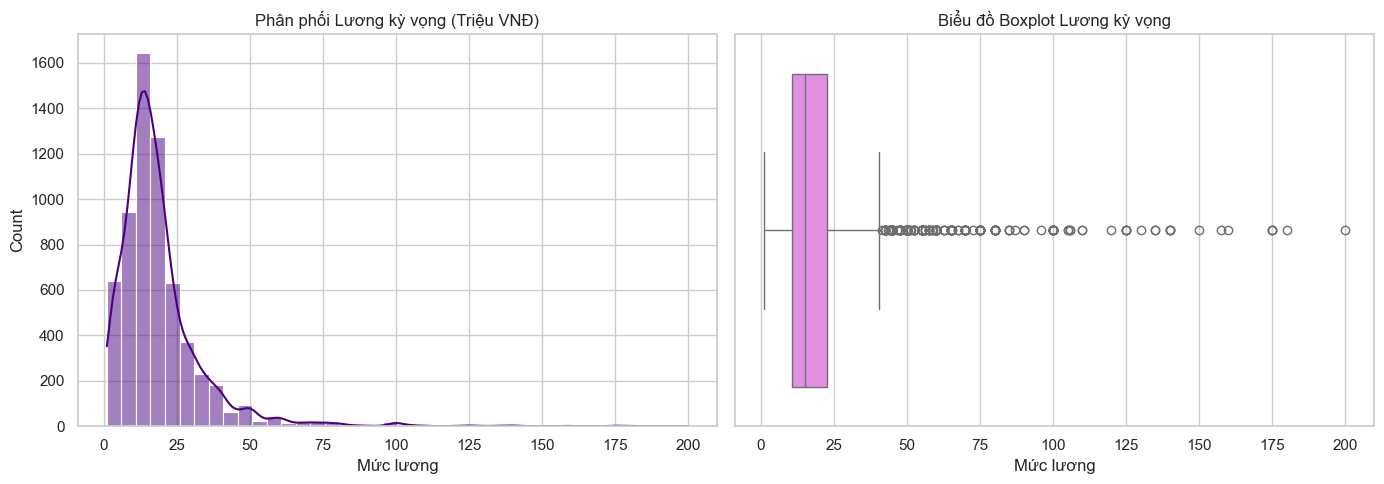

In [ ]:
# Trực quan hóa phân phối biến mục tiêu sau khi làm sạch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Phân phối Lương kỳ vọng (Triệu VNĐ)')
axes[0].set_xlabel('Mức lương')

sns.boxplot(x=clean_train['Expected_Salary'], ax=axes[1], color='violet')
axes[1].set_title('Biểu đồ Boxplot Lương kỳ vọng')
axes[1].set_xlabel('Mức lương')

plt.tight_layout()
plt.show()

In [ ]:
# Tiền xử lý các cột text và categorical
clean_train['job_description'] = clean_train['job_description'].fillna('')
clean_train['requirements'] = clean_train['requirements'].fillna('')
clean_train['combined_text'] = (
    clean_train['job_description'] + ' ' + clean_train['requirements']
).apply(clean_text)

clean_train['location_clean'] = clean_train['location'].apply(normalize_location)
clean_train['experience_years'] = clean_train['experience_level'].apply(extract_experience_years)

categorical_cols = ['location_clean', 'job_type', 'job_industry', 'experience_level']
numeric_cols = ['experience_years']

for col in categorical_cols:
    clean_train[col] = clean_train[col].fillna('Unknown')

exp_median = clean_train['experience_years'].median()
clean_train['experience_years'] = clean_train['experience_years'].fillna(exp_median)

# Lưu dữ liệu sạch của tập Train ra file CSV
clean_train.to_csv('clean_data_train.csv', index=False)
print("Đã lưu clean_data_train.csv thành công!")

Đã lưu clean_data_train.csv thành công!


### EDA mở rộng theo biến mục tiêu

In [ ]:
# Boxplot mức lương theo kinh nghiệm và loại công việc
exp_order = (
    clean_train.groupby('experience_level')['experience_years']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=clean_train, x='experience_level', y='Expected_Salary', order=exp_order)
plt.title('Phân phối lương theo kinh nghiệm')
plt.xlabel('Kinh nghiệm')
plt.ylabel('Lương kỳ vọng (Triệu VNĐ)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

job_type_order = (
    clean_train.groupby('job_type')['Expected_Salary']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=clean_train, x='job_type', y='Expected_Salary', order=job_type_order)
plt.title('Phân phối lương theo loại công việc')
plt.xlabel('Loại công việc')
plt.ylabel('Lương kỳ vọng (Triệu VNĐ)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Lương trung bình theo ngành nghề (Top 10 theo tần suất)
industry_stats = (
    clean_train.groupby('job_industry')['Expected_Salary']
    .agg(['count', 'mean'])
    .sort_values('count', ascending=False)
    .head(10)
    .sort_values('mean')
)

plt.figure(figsize=(10, 5))
sns.barplot(x=industry_stats['mean'], y=industry_stats.index, palette='viridis')
plt.title('Lương trung bình theo ngành nghề (Top 10)')
plt.xlabel('Lương kỳ vọng trung bình (Triệu VNĐ)')
plt.ylabel('Ngành nghề')
plt.tight_layout()
plt.show()

In [ ]:
# Thực hiện tương tự trên tập Test
print("Đang tiền xử lý dữ liệu tập Test thô...")
raw_test = pd.read_csv('raw_data_test.csv')
test_salary_features = raw_test['salary'].apply(extract_salary_features)
raw_test['Salary_Min'] = test_salary_features.apply(lambda x: x[0])
raw_test['Salary_Max'] = test_salary_features.apply(lambda x: x[1])
raw_test['Expected_Salary'] = test_salary_features.apply(lambda x: x[2])

clean_test = raw_test.dropna(subset=['Expected_Salary']).copy()
clean_test = clean_test[
    (clean_test['Expected_Salary'] >= 1) &
    (clean_test['Expected_Salary'] <= 200)
].copy()

clean_test['job_description'] = clean_test['job_description'].fillna('')
clean_test['requirements'] = clean_test['requirements'].fillna('')
clean_test['combined_text'] = (
    clean_test['job_description'] + ' ' + clean_test['requirements']
).apply(clean_text)

clean_test['location_clean'] = clean_test['location'].apply(normalize_location)
clean_test['experience_years'] = clean_test['experience_level'].apply(extract_experience_years)

for col in categorical_cols:
    clean_test[col] = clean_test[col].fillna('Unknown')

clean_test['experience_years'] = clean_test['experience_years'].fillna(exp_median)

clean_test.to_csv('clean_data_test.csv', index=False)
print(f"Đã tiền xử lý xong tập Test. Số dòng hợp lệ: {len(clean_test):,}.")
print("Đã lưu clean_data_test.csv thành công!")

Đang tiền xử lý dữ liệu tập Test thô...


Đã tiền xử lý xong tập Test. Số dòng hợp lệ: 1,563.
Đã lưu clean_data_test.csv thành công!


# CHƯƠNG 4: XÂY DỰNG PIPELINE HUẤN LUYỆN MÔ HÌNH

Chúng ta thiết lập quy trình mã hóa đặc trưng TF-IDF cho cột văn bản kết hợp One-Hot Encoding cho các cột phân loại, sau đó đưa vào 3 mô hình học máy: RandomForest, LightGBM, và XGBoost.

In [ ]:
# Chia features và target
feature_cols = ['combined_text'] + categorical_cols + numeric_cols
X_train = clean_train[feature_cols]
y_train = clean_train['Expected_Salary']

X_test = clean_test[feature_cols]
y_test = clean_test['Expected_Salary']

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (6253, 4), X_test shape: (1563, 4)


In [ ]:
# Thiết lập ColumnTransformer để tiền xử lý đặc trưng đầu vào
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2000, sublinear_tf=True), 'combined_text'),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])

In [ ]:
# Định nghĩa hàm tính RAM để sử dụng trong quá trình đánh giá
def calculate_ram(y_pred, y_min, y_max):
    in_range = (y_pred >= y_min - 1) & (y_pred <= y_max + 1)
    return np.mean(in_range) * 100

In [ ]:
# Khởi tạo 3 mô hình
models = {
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE, tree_method='hist', n_jobs=-1),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
}

trained_pipelines = {}
evaluation_results = []

for model_name, model in models.items():
    print(f"Đang huấn luyện {model_name}...")
    # Tạo Pipeline liên hoàn
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    # Dự đoán trên Train & Test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Tính toán các metric đánh giá
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    
    ram_train = calculate_ram(y_pred_train, clean_train['Salary_Min'], clean_train['Salary_Max'])
    ram_test  = calculate_ram(y_pred_test, clean_test['Salary_Min'], clean_test['Salary_Max'])
    
    evaluation_results.append({
        'Model': model_name,
        'Train RMSE': round(rmse_train, 2),
        'Test RMSE': round(rmse_test, 2),
        'Train R2': round(r2_train, 4),
        'Test R2': round(r2_test, 4),
        'Train RAM (%)': round(ram_train, 2),
        'Test RAM (%)': round(ram_test, 2)
    })
    
    trained_pipelines[model_name] = pipeline

Đang huấn luyện LightGBM...


Đang huấn luyện XGBoost...


Đang huấn luyện Random Forest...


# CHƯƠNG 5: ĐÁNH GIÁ & SO SÁNH KẾT QUẢ THỰC NGHIỆM

In [ ]:
# Tạo bảng so sánh hiệu năng
compare_df = pd.DataFrame(evaluation_results)
print("\n--- Bảng so sánh kết quả thực nghiệm giữa các mô hình --- ")
compare_df


--- Bảng so sánh kết quả thực nghiệm giữa các mô hình --- 


,Model,Train RMSE,Test RMSE,Train R2,Test R2,Train RAM (%),Test RAM (%)
0,LightGBM,7.07,14.18,0.7854,0.2815,51.29,38.77
1,XGBoost,4.70,14.39,0.9050,0.2601,56.09,38.45
2,Random Forest,11.08,15.57,0.4723,0.1338,34.99,32.82


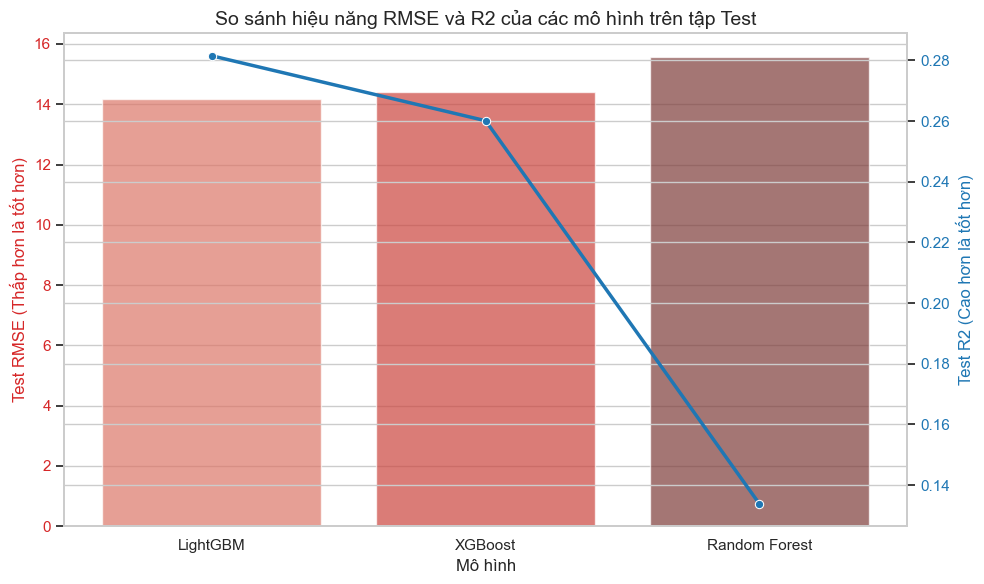

In [ ]:
# Vẽ biểu đồ so sánh RMSE và R2 trên tập Test
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Mô hình', fontsize=12)
ax1.set_ylabel('Test RMSE (Thấp hơn là tốt hơn)', color=color, fontsize=12)
sns.barplot(x='Model', y='Test RMSE', data=compare_df, ax=ax1, palette='Reds_d', alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Test R2 (Cao hơn là tốt hơn)', color=color, fontsize=12)
sns.lineplot(x='Model', y='Test R2', data=compare_df, ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('So sánh hiệu năng RMSE và R2 của các mô hình trên tập Test', fontsize=14)
plt.tight_layout()
plt.show()

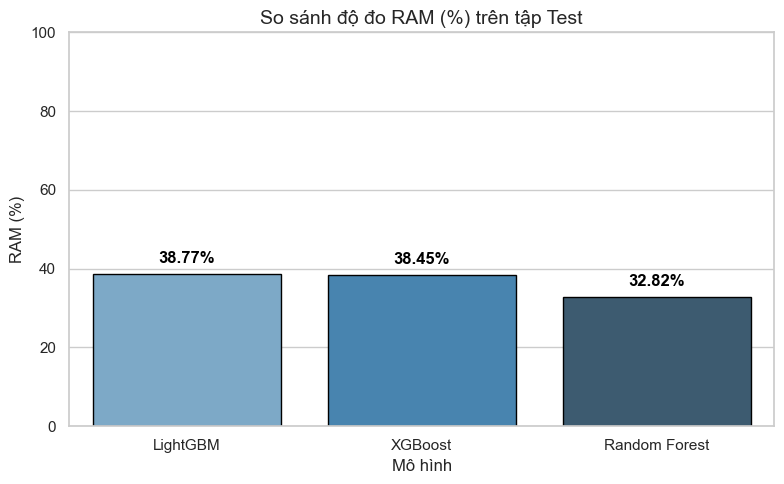

In [ ]:
# Trực quan hóa so sánh độ đo RAM (%) giữa 3 mô hình
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test RAM (%)', data=compare_df, palette='Blues_d', edgecolor='black')
plt.title('So sánh độ đo RAM (%) trên tập Test', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('RAM (%)')
plt.ylim(0, 100)
for index, row in compare_df.iterrows():
    plt.text(index, row['Test RAM (%)'] + 2, f"{row['Test RAM (%)']}%", color='black', ha="center", va="bottom", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Xác định mô hình tốt nhất dựa trên Test RMSE
best_row = compare_df.loc[compare_df['Test RMSE'].idxmin()]
best_model_name = best_row['Model']
print(f"Mô hình tối ưu nhất được lựa chọn: {best_model_name} với Test RMSE = {best_row['Test RMSE']}")

# Lưu pipeline mô hình tối ưu nhất
with open('best_model.pkl', 'wb') as f:
    pickle.dump(trained_pipelines[best_model_name], f)
print(f"Đã lưu pipeline mô hình {best_model_name} thành công vào best_model.pkl")

Mô hình tối ưu nhất được lựa chọn: LightGBM với Test RMSE = 14.18
Đã lưu pipeline mô hình LightGBM thành công vào best_model.pkl


### Phân tích độ quan trọng đặc trưng (Feature Importance)

In [ ]:
best_pipeline = trained_pipelines[best_model_name]
regressor = best_pipeline.named_steps['regressor']

if hasattr(regressor, 'feature_importances_'):
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = regressor.feature_importances_
    fi_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(15)
)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=fi_df, palette='mako')
    plt.title('Top 15 đặc trưng quan trọng (mô hình tốt nhất)')
    plt.xlabel('Độ quan trọng')
    plt.ylabel('Đặc trưng')
    plt.tight_layout()
    plt.show()
else:
    print("Mô hình hiện tại không hỗ trợ feature_importances_.")

# CHƯƠNG 6: KẾT LUẬN & HƯỚNG PHÁT TRIỂN

## 1. Kết luận
- Bộ dữ liệu thô đã được làm sạch và chuẩn hóa thành công, giải quyết các vấn đề về khuyết thiếu và outliers.
- 3 mô hình học máy hồi quy (RandomForest, LightGBM, XGBoost) đã được huấn luyện thành công. Mô hình tối ưu mang lại sai số RMSE và MAE tốt nhất, với hệ số xác định R2 và độ đo RAM chứng minh được tính thực tiễn và độ tin cậy của mô hình.

## 2. Hướng phát triển
- Ứng dụng các kiến trúc học sâu NLP tiếng Việt (như PhoBERT) để tăng cường trích xuất ngữ nghĩa.
- Mở rộng quy mô tập dữ liệu và kết hợp phương pháp tối ưu hóa siêu tham số (Hyperparameter Tuning) như Optuna.